# Cell Threshold Tuning Notebook

This notebook helps you tune **cell voltage / temperature thresholds** using your real field data.

It does 4 things:

1. Loads all available `gold_cells` and `silver_cells` files across dates
2. Computes global distributions for voltage, temperature, module, and pack metrics
3. Produces a few compact outputs you can share back
4. Suggests data-driven threshold candidates from percentiles

## What to share back

Please copy/share the outputs of these sections:

- **Section 3:** Available dates and row counts
- **Section 5:** Voltage distribution summary
- **Section 6:** Temperature distribution summary
- **Section 7:** Module / pack metric percentiles
- **Section 8:** Suggested threshold candidates
- **Section 9:** Sample daily health report table (optional but useful)

That will be enough to tune your thresholds properly.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
SILVER_CELLS_DIR = DATA_DIR / "silver_cells"
GOLD_CELLS_DIR = DATA_DIR / "gold_cells"
MODULE_FEATURES_DIR = GOLD_CELLS_DIR / "module_features"
PACK_FEATURES_DIR = GOLD_CELLS_DIR / "pack_features"
DAILY_HEALTH_DIR = GOLD_CELLS_DIR / "daily_health_reports"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("SILVER_CELLS_DIR exists:", SILVER_CELLS_DIR.exists())
print("MODULE_FEATURES_DIR exists:", MODULE_FEATURES_DIR.exists())
print("PACK_FEATURES_DIR exists:", PACK_FEATURES_DIR.exists())
print("DAILY_HEALTH_DIR exists:", DAILY_HEALTH_DIR.exists())


PROJECT_ROOT: /Users/rhythmparashar/Desktop/ev-predictive-analytics
DATA_DIR: /Users/rhythmparashar/Desktop/ev-predictive-analytics/data
SILVER_CELLS_DIR exists: True
MODULE_FEATURES_DIR exists: True
PACK_FEATURES_DIR exists: True
DAILY_HEALTH_DIR exists: True


## 1) Helper functions


In [2]:
def list_partition_files(base_dir: Path):
    if not base_dir.exists():
        return []
    return sorted(base_dir.glob("dt=*/vehicle_id=*.parquet"))

def dt_from_path(path: Path) -> str:
    return path.parent.name.replace("dt=", "")

def vehicle_from_path(path: Path) -> str:
    return path.stem.replace("vehicle_id=", "")

def summarize_partition_files(files):
    rows = []
    for p in files:
        try:
            df = pd.read_parquet(p)
            rows.append({
                "dt": dt_from_path(p),
                "vehicle_id": vehicle_from_path(p),
                "rows": len(df),
                "path": str(p),
            })
        except Exception as e:
            rows.append({
                "dt": dt_from_path(p),
                "vehicle_id": vehicle_from_path(p),
                "rows": None,
                "path": str(p),
                "error": str(e),
            })
    if not rows:
        return pd.DataFrame(columns=["dt", "vehicle_id", "rows", "path"])
    return pd.DataFrame(rows).sort_values(["dt", "vehicle_id"]).reset_index(drop=True)

def read_all_parquets(base_dir: Path) -> pd.DataFrame:
    files = list_partition_files(base_dir)
    if not files:
        return pd.DataFrame()
    frames = []
    for p in files:
        df = pd.read_parquet(p)
        df = df.copy()
        if "dt" not in df.columns:
            df["dt"] = dt_from_path(p)
        if "vehicle_id" not in df.columns:
            df["vehicle_id"] = vehicle_from_path(p)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def percentile_table(series: pd.Series, name: str) -> pd.DataFrame:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return pd.DataFrame([{"metric": name, "count": 0}])
    q = s.quantile([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]).to_dict()
    return pd.DataFrame([{
        "metric": name,
        "count": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "p01": float(q.get(0.01)),
        "p05": float(q.get(0.05)),
        "p10": float(q.get(0.10)),
        "p50": float(q.get(0.50)),
        "p90": float(q.get(0.90)),
        "p95": float(q.get(0.95)),
        "p99": float(q.get(0.99)),
        "max": float(s.max()),
    }])

def stack_metric_columns(df: pd.DataFrame, prefixes: list[str]) -> pd.Series:
    cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]
    if not cols:
        return pd.Series(dtype="float64")
    stacked = df[cols].stack(dropna=True)
    return pd.to_numeric(stacked, errors="coerce").dropna()

def combine_percentile_tables(pairs):
    tables = []
    for name, series in pairs:
        tables.append(percentile_table(series, name))
    return pd.concat(tables, ignore_index=True)


## 2) Discover what data is available


In [3]:
silver_files = list_partition_files(SILVER_CELLS_DIR)
module_files = list_partition_files(MODULE_FEATURES_DIR)
pack_files = list_partition_files(PACK_FEATURES_DIR)
daily_files = list_partition_files(DAILY_HEALTH_DIR)

print("silver_cells files:", len(silver_files))
print("module_features files:", len(module_files))
print("pack_features files:", len(pack_files))
print("daily_health_reports files:", len(daily_files))


silver_cells files: 47
module_features files: 47
pack_features files: 47
daily_health_reports files: 47


## 3) Available dates and row counts  ← share this output


In [4]:
silver_summary = summarize_partition_files(silver_files)
module_summary = summarize_partition_files(module_files)
pack_summary = summarize_partition_files(pack_files)
daily_summary = summarize_partition_files(daily_files)

print("silver_cells summary")
display(silver_summary)

print("\nmodule_features summary")
display(module_summary)

print("\npack_features summary")
display(pack_summary)

print("\ndaily_health_reports summary")
display(daily_summary)


silver_cells summary


,dt,vehicle_id,rows,path
0,2026-01-22,EV01,26900,/Users/rhythmparashar/Desktop/ev-predictive-an...
1,2026-01-23,EV01,27119,/Users/rhythmparashar/Desktop/ev-predictive-an...
2,2026-01-24,EV01,52585,/Users/rhythmparashar/Desktop/ev-predictive-an...
3,2026-01-25,EV01,533,/Users/rhythmparashar/Desktop/ev-predictive-an...
4,2026-01-26,EV01,22960,/Users/rhythmparashar/Desktop/ev-predictive-an...
5,2026-01-27,EV01,79012,/Users/rhythmparashar/Desktop/ev-predictive-an...
6,2026-01-28,EV01,53849,/Users/rhythmparashar/Desktop/ev-predictive-an...
7,2026-01-29,EV01,83526,/Users/rhythmparashar/Desktop/ev-predictive-an...
8,2026-01-30,EV01,106440,/Users/rhythmparashar/Desktop/ev-predictive-an...
9,2026-01-31,EV01,14980,/Users/rhythmparashar/Desktop/ev-predictive-an...



module_features summary


,dt,vehicle_id,rows,path
0,2026-01-22,EV01,26896,/Users/rhythmparashar/Desktop/ev-predictive-an...
1,2026-01-23,EV01,24270,/Users/rhythmparashar/Desktop/ev-predictive-an...
2,2026-01-24,EV01,51575,/Users/rhythmparashar/Desktop/ev-predictive-an...
3,2026-01-25,EV01,522,/Users/rhythmparashar/Desktop/ev-predictive-an...
4,2026-01-26,EV01,22869,/Users/rhythmparashar/Desktop/ev-predictive-an...
5,2026-01-27,EV01,75918,/Users/rhythmparashar/Desktop/ev-predictive-an...
6,2026-01-28,EV01,53661,/Users/rhythmparashar/Desktop/ev-predictive-an...
7,2026-01-29,EV01,75620,/Users/rhythmparashar/Desktop/ev-predictive-an...
8,2026-01-30,EV01,106345,/Users/rhythmparashar/Desktop/ev-predictive-an...
9,2026-01-31,EV01,11380,/Users/rhythmparashar/Desktop/ev-predictive-an...



pack_features summary


,dt,vehicle_id,rows,path
0,2026-01-22,EV01,26896,/Users/rhythmparashar/Desktop/ev-predictive-an...
1,2026-01-23,EV01,24270,/Users/rhythmparashar/Desktop/ev-predictive-an...
2,2026-01-24,EV01,51575,/Users/rhythmparashar/Desktop/ev-predictive-an...
3,2026-01-25,EV01,522,/Users/rhythmparashar/Desktop/ev-predictive-an...
4,2026-01-26,EV01,22869,/Users/rhythmparashar/Desktop/ev-predictive-an...
5,2026-01-27,EV01,75918,/Users/rhythmparashar/Desktop/ev-predictive-an...
6,2026-01-28,EV01,53661,/Users/rhythmparashar/Desktop/ev-predictive-an...
7,2026-01-29,EV01,75620,/Users/rhythmparashar/Desktop/ev-predictive-an...
8,2026-01-30,EV01,106345,/Users/rhythmparashar/Desktop/ev-predictive-an...
9,2026-01-31,EV01,11380,/Users/rhythmparashar/Desktop/ev-predictive-an...



daily_health_reports summary


,dt,vehicle_id,rows,path
0,2026-01-22,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
1,2026-01-23,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
2,2026-01-24,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
3,2026-01-25,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
4,2026-01-26,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
5,2026-01-27,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
6,2026-01-28,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
7,2026-01-29,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
8,2026-01-30,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...
9,2026-01-31,EV01,5,/Users/rhythmparashar/Desktop/ev-predictive-an...


## 4) Load all datasets


In [5]:
silver_all = read_all_parquets(SILVER_CELLS_DIR)
module_all = read_all_parquets(MODULE_FEATURES_DIR)
pack_all = read_all_parquets(PACK_FEATURES_DIR)
daily_all = read_all_parquets(DAILY_HEALTH_DIR)

print("silver_all shape:", silver_all.shape)
print("module_all shape:", module_all.shape)
print("pack_all shape:", pack_all.shape)
print("daily_all shape:", daily_all.shape)


silver_all shape: (1500120, 274)
module_all shape: (1473883, 39)
pack_all shape: (1473883, 10)
daily_all shape: (235, 12)


## 5) Voltage distribution summary  ← share this output


In [6]:
cell_voltage_series = stack_metric_columns(silver_all, [f"M{i}_C" for i in range(1, 6)])
module_voltage_std_series = stack_metric_columns(module_all, [f"module_{i}_voltage_std" for i in range(1, 6)])
module_voltage_range_series = stack_metric_columns(module_all, [f"module_{i}_voltage_range" for i in range(1, 6)])

pack_voltage_range_series = (
    pd.to_numeric(pack_all["pack_voltage_range"], errors="coerce").dropna()
    if "pack_voltage_range" in pack_all.columns else pd.Series(dtype="float64")
)
pack_voltage_std_series = (
    pd.to_numeric(pack_all["pack_voltage_std"], errors="coerce").dropna()
    if "pack_voltage_std" in pack_all.columns else pd.Series(dtype="float64")
)

voltage_summary = combine_percentile_tables([
    ("cell_voltage_v", cell_voltage_series),
    ("module_voltage_std_v", module_voltage_std_series),
    ("module_voltage_range_v", module_voltage_range_series),
    ("pack_voltage_std_v", pack_voltage_std_series),
    ("pack_voltage_range_v", pack_voltage_range_series),
])

display(voltage_summary)


/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = df[cols].stack(dropna=True)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = df[cols].stack(dropna=True)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 

,metric,count,mean,std,min,p01,p05,p10,p50,p90,p95,p99,max
0,cell_voltage_v,266829332,3.309137,0.126657,0.000000,3.227000,3.257000,3.269000,3.311000,3.382000,3.396000,3.411000,4.090000
1,module_voltage_std_v,7369293,0.008300,0.008662,0.000000,0.000586,0.000639,0.000681,0.009478,0.015187,0.019178,0.028392,1.661437
2,module_voltage_range_v,7369293,0.039865,0.036546,0.000000,0.002000,0.003000,0.003000,0.048000,0.075000,0.095000,0.125000,3.344000
3,pack_voltage_std_v,1473863,0.009020,0.007908,0.000554,0.001825,0.002270,0.003282,0.008304,0.014765,0.018871,0.028443,1.577250
4,pack_voltage_range_v,1473863,0.059539,0.029351,0.003000,0.019000,0.028000,0.034000,0.057000,0.083000,0.102000,0.132000,3.344000


## 6) Temperature distribution summary  ← share this output


In [7]:
cell_temp_series = stack_metric_columns(silver_all, [f"M{i}_T" for i in range(1, 6)])
module_temp_mean_series = stack_metric_columns(module_all, [f"module_{i}_temp_mean" for i in range(1, 6)])
module_temp_range_series = stack_metric_columns(module_all, [f"module_{i}_temp_range" for i in range(1, 6)])

pack_temp_range_series = (
    pd.to_numeric(pack_all["pack_temp_range"], errors="coerce").dropna()
    if "pack_temp_range" in pack_all.columns else pd.Series(dtype="float64")
)

temp_summary = combine_percentile_tables([
    ("cell_temp_c", cell_temp_series),
    ("module_temp_mean_c", module_temp_mean_series),
    ("module_temp_range_c", module_temp_range_series),
    ("pack_temp_range_c", pack_temp_range_series),
])

display(temp_summary)


/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = df[cols].stack(dropna=True)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = df[cols].stack(dropna=True)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_47956/3590265983.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 

,metric,count,mean,std,min,p01,p05,p10,p50,p90,p95,p99,max
0,cell_temp_c,134715790,31.380045,5.172105,0.0,21.000000,23.000000,26.000000,30.000000,38.000000,41.000000,42.000000,120.000000
1,module_temp_mean_c,7369382,31.391988,3.947242,18.2,22.611111,24.111111,25.944444,31.555556,36.611111,37.722222,39.222222,43.055556
2,module_temp_range_c,7369382,7.657140,4.786161,0.0,1.000000,2.000000,2.000000,7.000000,14.000000,16.000000,26.000000,117.000000
3,pack_temp_range_c,1473882,10.941155,9.301974,1.0,1.000000,3.000000,3.000000,8.000000,29.000000,32.000000,41.000000,117.000000


## 7) Daily-health metric percentiles  ← share this output


In [8]:
daily_metric_pairs = []
for col in [
    "avg_voltage_std",
    "max_voltage_range",
    "avg_temp_range",
    "max_temp_spike",
    "pct_time_imbalanced",
]:
    if col in daily_all.columns:
        daily_metric_pairs.append((col, pd.to_numeric(daily_all[col], errors="coerce").dropna()))

daily_summary_metrics = combine_percentile_tables(daily_metric_pairs) if daily_metric_pairs else pd.DataFrame()
display(daily_summary_metrics)


,metric,count,mean,std,min,p01,p05,p10,p50,p90,p95,p99,max
0,avg_voltage_std,235,0.011185,0.006016,0.001722,0.001731,0.002279,0.002841,0.011292,0.016165,0.022742,0.029481,0.048149
1,max_voltage_range,235,0.456157,0.908892,0.038000,0.047000,0.059000,0.068400,0.147000,0.665400,3.326000,3.337000,3.344000
2,avg_temp_range,235,7.266327,3.837594,1.000000,1.448410,2.366035,3.013122,7.138474,10.719126,11.976613,21.840293,26.436735
3,max_temp_spike,235,25.425532,24.808794,1.000000,2.000000,4.000000,6.000000,14.000000,60.000000,60.000000,117.000000,117.000000
4,pct_time_imbalanced,235,0.103716,0.173206,0.000000,0.000000,0.000000,0.000000,0.015381,0.326442,0.525689,0.784955,0.803167


## 8) Suggested threshold candidates  ← share this output


In [9]:
def get_quantile(summary_df: pd.DataFrame, metric: str, q_col: str):
    row = summary_df[summary_df["metric"] == metric]
    if row.empty or q_col not in row.columns:
        return np.nan
    return float(row.iloc[0][q_col])

suggestions = []

mvr_p90 = get_quantile(voltage_summary, "module_voltage_range_v", "p90")
mvr_p95 = get_quantile(voltage_summary, "module_voltage_range_v", "p95")
mtr_p95 = get_quantile(temp_summary, "module_temp_range_c", "p95")
mtm_p95 = get_quantile(temp_summary, "module_temp_mean_c", "p95")
mtm_p99 = get_quantile(temp_summary, "module_temp_mean_c", "p99")
pti_p90 = get_quantile(daily_summary_metrics, "pct_time_imbalanced", "p90")
pti_p95 = get_quantile(daily_summary_metrics, "pct_time_imbalanced", "p95")

suggestions.append({
    "parameter": "voltage.imbalance_warn_mv",
    "current_guess": 50,
    "suggested_from_data": None if np.isnan(mvr_p90) else round(mvr_p90 * 1000, 1),
    "basis": "module_voltage_range_v p90"
})
suggestions.append({
    "parameter": "voltage.imbalance_alert_mv",
    "current_guess": 100,
    "suggested_from_data": None if np.isnan(mvr_p95) else round(mvr_p95 * 1000, 1),
    "basis": "module_voltage_range_v p95"
})
suggestions.append({
    "parameter": "temperature.hotspot_delta_c",
    "current_guess": 5,
    "suggested_from_data": None if np.isnan(mtr_p95) else round(mtr_p95, 2),
    "basis": "module_temp_range_c p95"
})
suggestions.append({
    "parameter": "temperature.warn_c",
    "current_guess": 45,
    "suggested_from_data": None if np.isnan(mtm_p95) else round(mtm_p95, 2),
    "basis": "module_temp_mean_c p95"
})
suggestions.append({
    "parameter": "temperature.alert_c",
    "current_guess": 55,
    "suggested_from_data": None if np.isnan(mtm_p99) else round(mtm_p99, 2),
    "basis": "module_temp_mean_c p99"
})
suggestions.append({
    "parameter": "health_report.pct_time_imbalanced_warn",
    "current_guess": 0.1,
    "suggested_from_data": None if np.isnan(pti_p90) else round(pti_p90, 3),
    "basis": "pct_time_imbalanced p90"
})
suggestions.append({
    "parameter": "health_report.pct_time_imbalanced_alert",
    "current_guess": 0.3,
    "suggested_from_data": None if np.isnan(pti_p95) else round(pti_p95, 3),
    "basis": "pct_time_imbalanced p95"
})

suggested_thresholds = pd.DataFrame(suggestions)
display(suggested_thresholds)


,parameter,current_guess,suggested_from_data,basis
0,voltage.imbalance_warn_mv,50.0,75.000,module_voltage_range_v p90
1,voltage.imbalance_alert_mv,100.0,95.000,module_voltage_range_v p95
2,temperature.hotspot_delta_c,5.0,16.000,module_temp_range_c p95
3,temperature.warn_c,45.0,37.720,module_temp_mean_c p95
4,temperature.alert_c,55.0,39.220,module_temp_mean_c p99
5,health_report.pct_time_imbalanced_warn,0.1,0.326,pct_time_imbalanced p90
6,health_report.pct_time_imbalanced_alert,0.3,0.526,pct_time_imbalanced p95


## 9) Sample daily health report table  ← optional but useful to share


In [10]:
if not daily_all.empty:
    cols = [c for c in [
        "dt",
        "vehicle_id",
        "module_id",
        "status",
        "avg_voltage_std",
        "max_voltage_range",
        "avg_temp_range",
        "max_temp_spike",
        "pct_time_imbalanced",
        "trend_direction",
    ] if c in daily_all.columns]
    display(daily_all[cols].sort_values(["dt", "vehicle_id", "module_id"]).tail(20))
else:
    print("No daily health report files found yet.")


,dt,vehicle_id,module_id,status,avg_voltage_std,max_voltage_range,avg_temp_range,max_temp_spike,pct_time_imbalanced,trend_direction
215,2026-03-14,EV01,1,Degraded Cell,0.016972,0.316,9.793154,14.0,0.325535,worsening
216,2026-03-14,EV01,2,Degraded Cell,0.016975,0.315,9.800135,15.0,0.326525,worsening
217,2026-03-14,EV01,3,Degraded Cell,0.016993,0.353,9.796488,15.0,0.326317,worsening
218,2026-03-14,EV01,4,Degraded Cell,0.017002,0.352,9.799354,15.0,0.326004,worsening
219,2026-03-14,EV01,5,Degraded Cell,0.016977,0.353,9.801803,15.0,0.325171,worsening
220,2026-03-15,EV01,1,Critical,0.024052,0.498,10.590943,16.0,0.748617,worsening
221,2026-03-15,EV01,2,Critical,0.024054,0.492,10.577424,16.0,0.748925,worsening
222,2026-03-15,EV01,3,Critical,0.024051,0.490,10.586457,16.0,0.748433,worsening
223,2026-03-15,EV01,4,Critical,0.024063,0.489,10.582893,16.0,0.749601,worsening
224,2026-03-15,EV01,5,Critical,0.024047,0.503,10.582340,16.0,0.747204,worsening


## 10) Simple plots (optional)


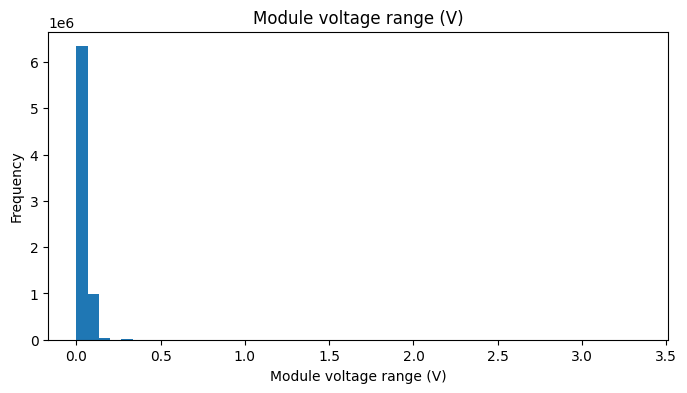

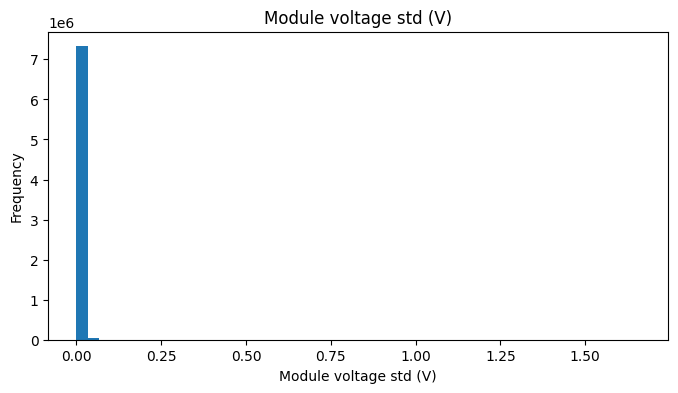

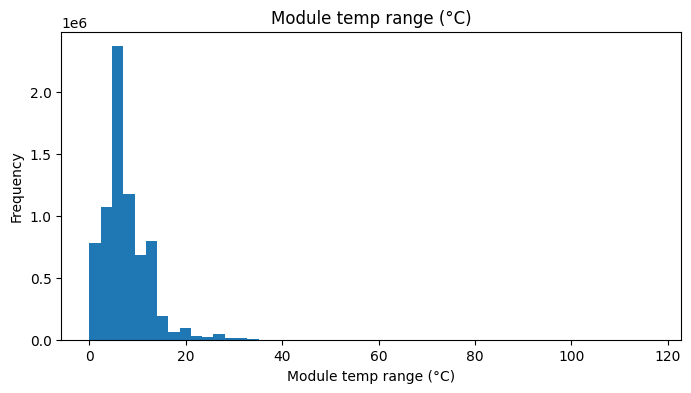

In [11]:
plot_specs = [
    ("Module voltage range (V)", module_voltage_range_series),
    ("Module voltage std (V)", module_voltage_std_series),
    ("Module temp range (°C)", module_temp_range_series),
]

for title, series in plot_specs:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        print(f"Skipping plot: {title} (no data)")
        continue
    plt.figure(figsize=(8, 4))
    plt.hist(s, bins=50)
    plt.title(title)
    plt.xlabel(title)
    plt.ylabel("Frequency")
    plt.show()


## 11) Notes for threshold tuning

A good starting rule is:

- **warn** thresholds near **p90**
- **alert** thresholds near **p95**
- **critical** should usually require a combination of:
  - very high voltage range
  - very high imbalance persistence
  - confirmed thermal issue

Please share the outputs from sections **3, 5, 6, 7, 8**.


Voltage columns: 180
Temp columns: 90
Sample voltage cols: ['M1_C1', 'M1_C2', 'M1_C3', 'M1_C4', 'M1_C5', 'M1_C6', 'M1_C7', 'M1_C8', 'M1_C9', 'M1_C10']
Sample temp cols: ['M1_T1', 'M1_T2', 'M1_T3', 'M1_T4', 'M1_T5', 'M1_T6', 'M1_T7', 'M1_T8', 'M1_T9', 'M1_T10']

Voltage observations: 266,829,332
Temperature observations: 134,715,790


,cell_voltage_v,cell_temp_c
count,2.668293e+08,1.347158e+08
mean,3.309137e+00,3.138005e+01
std,1.266566e-01,5.172105e+00
min,0.000000e+00,0.000000e+00
1%,3.227000e+00,2.100000e+01
5%,3.257000e+00,2.300000e+01
10%,3.269000e+00,2.600000e+01
50%,3.311000e+00,3.000000e+01
90%,3.382000e+00,3.800000e+01
95%,3.396000e+00,4.100000e+01



Suspicious voltage values:


5679260    0.0
5679261    0.0
5679262    0.0
5679263    0.0
5679328    0.0
5679329    0.0
5679330    0.0
5679331    0.0
5679344    0.0
5679345    0.0
5679346    0.0
5679347    0.0
5679372    0.0
5679373    0.0
5679374    0.0
5679375    0.0
5679508    0.0
5679509    0.0
5679510    0.0
5679511    0.0
5679524    0.0
5679525    0.0
5679526    0.0
5679527    0.0
5679584    0.0
5679585    0.0
5679586    0.0
5679587    0.0
5679688    0.0
5679689    0.0
5679690    0.0
5679691    0.0
5679764    0.0
5679765    0.0
5679766    0.0
5679767    0.0
5679868    0.0
5679869    0.0
5679870    0.0
5679871    0.0
5679944    0.0
5679945    0.0
5679946    0.0
5679947    0.0
5680048    0.0
5680049    0.0
5680050    0.0
5680051    0.0
5680124    0.0
5680125    0.0
Name: cell_voltage_v, dtype: float64


Suspicious temperature values:


675026    0.0
675116    0.0
675206    0.0
675386    0.0
675746    0.0
675836    0.0
675926    0.0
676016    0.0
680786    0.0
680876    0.0
680966    0.0
681056    0.0
681146    0.0
681236    0.0
681326    0.0
681416    0.0
681506    0.0
681596    0.0
681686    0.0
681776    0.0
681866    0.0
681956    0.0
682046    0.0
682136    0.0
682226    0.0
682316    0.0
682406    0.0
682496    0.0
682586    0.0
682676    0.0
682766    0.0
682856    0.0
682946    0.0
683036    0.0
683126    0.0
683216    0.0
683306    0.0
683396    0.0
683486    0.0
683576    0.0
683666    0.0
683756    0.0
683846    0.0
683936    0.0
684026    0.0
684116    0.0
684206    0.0
684296    0.0
684386    0.0
684476    0.0
Name: cell_temp_c, dtype: float64


Counts of suspicious values:
Voltage == 0           : 349928
Voltage < 2.5          : 349928
Voltage > 4.0          : 283
Temp == 0              : 78960
Temp > 70              : 14913
Temp < -20             : 0


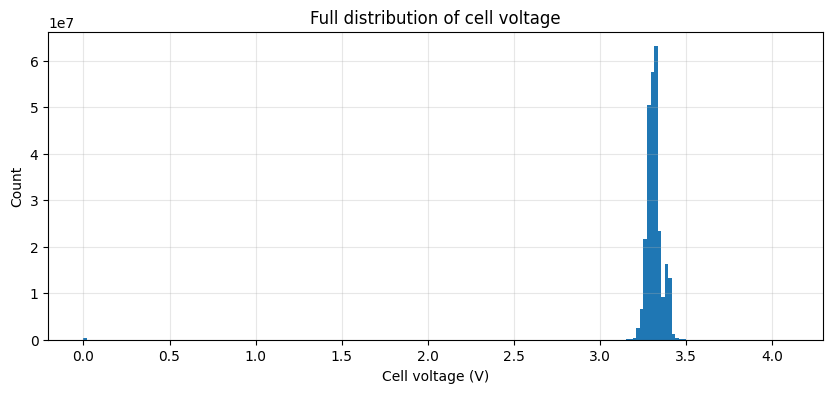

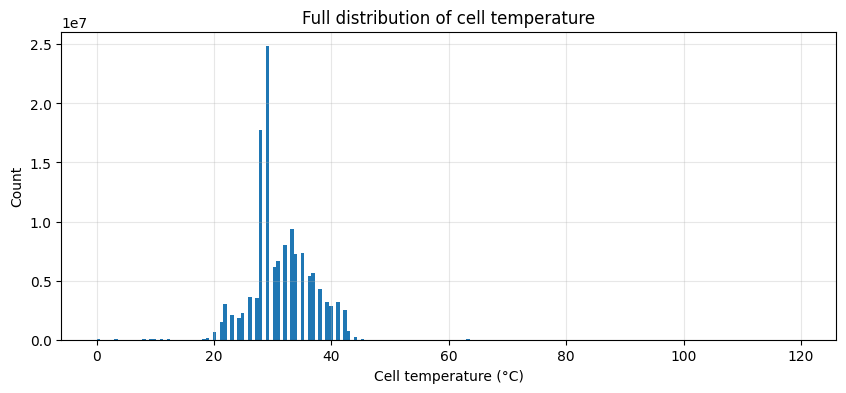

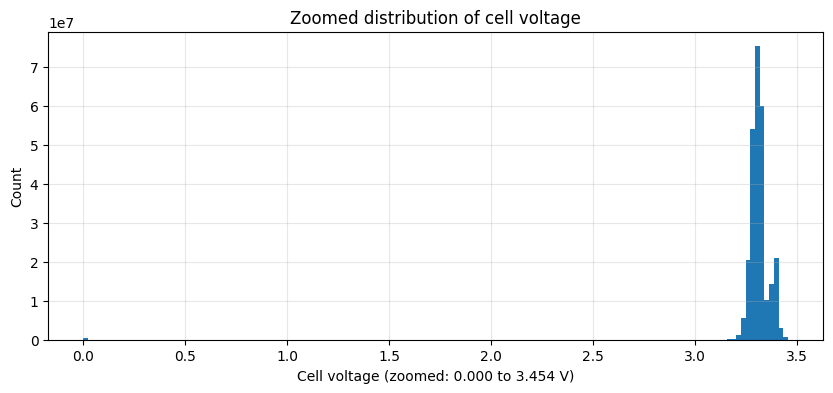

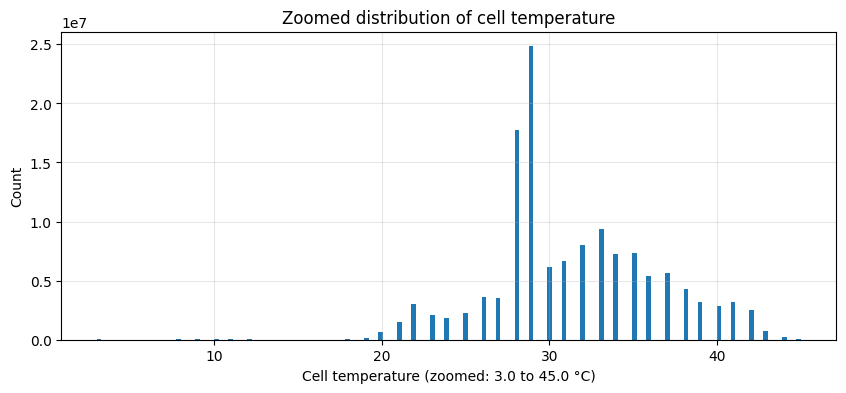

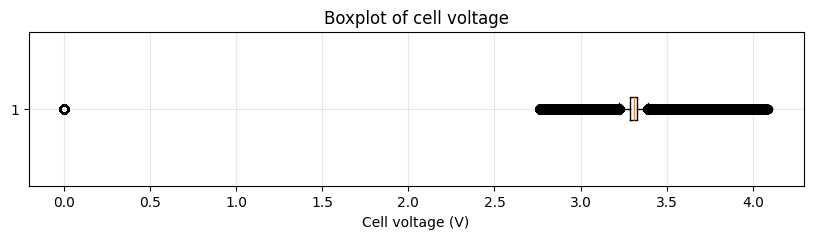

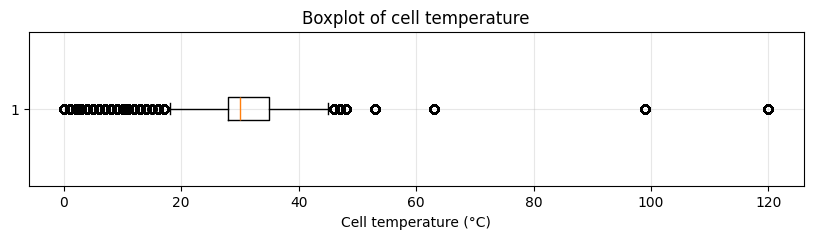

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# 1) Identify raw voltage/temp cols
# ---------------------------------
voltage_cols = [c for c in silver_all.columns if c.startswith("M") and "_C" in c]
temp_cols = [c for c in silver_all.columns if c.startswith("M") and "_T" in c]

print(f"Voltage columns: {len(voltage_cols)}")
print(f"Temp columns: {len(temp_cols)}")
print("Sample voltage cols:", voltage_cols[:10])
print("Sample temp cols:", temp_cols[:10])

if not voltage_cols or not temp_cols:
    raise ValueError("Could not find expected M?_C? / M?_T? columns.")

# ---------------------------------
# 2) Flatten into long 1D arrays
# ---------------------------------
voltage_values = silver_all[voltage_cols].to_numpy().ravel()
temp_values = silver_all[temp_cols].to_numpy().ravel()

voltage_values = pd.Series(voltage_values, name="cell_voltage_v")
temp_values = pd.Series(temp_values, name="cell_temp_c")

voltage_values = pd.to_numeric(voltage_values, errors="coerce").dropna()
temp_values = pd.to_numeric(temp_values, errors="coerce").dropna()

print(f"\nVoltage observations: {len(voltage_values):,}")
print(f"Temperature observations: {len(temp_values):,}")

# ---------------------------------
# 3) Summary stats
# ---------------------------------
summary = pd.concat(
    [
        voltage_values.describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]),
        temp_values.describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]),
    ],
    axis=1
)
summary.columns = ["cell_voltage_v", "cell_temp_c"]
display(summary)

# ---------------------------------
# 4) Show suspicious values
# ---------------------------------
print("\nSuspicious voltage values:")
display(voltage_values[(voltage_values == 0) | (voltage_values < 2.5) | (voltage_values > 4.0)].head(50))

print("\nSuspicious temperature values:")
display(temp_values[(temp_values == 0) | (temp_values > 70) | (temp_values < -20)].head(50))

print("\nCounts of suspicious values:")
print("Voltage == 0           :", int((voltage_values == 0).sum()))
print("Voltage < 2.5          :", int((voltage_values < 2.5).sum()))
print("Voltage > 4.0          :", int((voltage_values > 4.0).sum()))
print("Temp == 0              :", int((temp_values == 0).sum()))
print("Temp > 70              :", int((temp_values > 70).sum()))
print("Temp < -20             :", int((temp_values < -20).sum()))

# ---------------------------------
# 5) Full histograms
# ---------------------------------
plt.figure(figsize=(10, 4))
plt.hist(voltage_values, bins=200)
plt.xlabel("Cell voltage (V)")
plt.ylabel("Count")
plt.title("Full distribution of cell voltage")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(temp_values, bins=200)
plt.xlabel("Cell temperature (°C)")
plt.ylabel("Count")
plt.title("Full distribution of cell temperature")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------
# 6) Zoomed histograms
# ---------------------------------
v_lo, v_hi = voltage_values.quantile([0.001, 0.999])
t_lo, t_hi = temp_values.quantile([0.001, 0.999])

plt.figure(figsize=(10, 4))
plt.hist(voltage_values[(voltage_values >= v_lo) & (voltage_values <= v_hi)], bins=150)
plt.xlabel(f"Cell voltage (zoomed: {v_lo:.3f} to {v_hi:.3f} V)")
plt.ylabel("Count")
plt.title("Zoomed distribution of cell voltage")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(temp_values[(temp_values >= t_lo) & (temp_values <= t_hi)], bins=150)
plt.xlabel(f"Cell temperature (zoomed: {t_lo:.1f} to {t_hi:.1f} °C)")
plt.ylabel("Count")
plt.title("Zoomed distribution of cell temperature")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------
# 7) Boxplots
# ---------------------------------
plt.figure(figsize=(10, 2))
plt.boxplot(voltage_values, vert=False, showfliers=True)
plt.xlabel("Cell voltage (V)")
plt.title("Boxplot of cell voltage")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 2))
plt.boxplot(temp_values, vert=False, showfliers=True)
plt.xlabel("Cell temperature (°C)")
plt.title("Boxplot of cell temperature")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Display outlier counts only, without pairwise/combo checks

print("\n===== VOLTAGE OUTLIERS =====")
total_v = len(voltage_values)

v_zero = int((voltage_values == 0).sum())
v_low_25 = int((voltage_values < 2.5).sum())
v_high_40 = int((voltage_values > 4.0).sum())
v_low_30 = int((voltage_values < 3.0).sum())
v_band_30_35 = int(voltage_values.between(3.0, 3.5).sum())

print(f"Total observations        : {total_v:,}")
print(f"Voltage == 0              : {v_zero:,} ({v_zero/total_v:.6%})")
print(f"Voltage < 2.5             : {v_low_25:,} ({v_low_25/total_v:.6%})")
print(f"Voltage > 4.0             : {v_high_40:,} ({v_high_40/total_v:.6%})")
print(f"Voltage < 3.0             : {v_low_30:,} ({v_low_30/total_v:.6%})")
print(f"Voltage in 3.0–3.5        : {v_band_30_35:,} ({v_band_30_35/total_v:.6%})")

print("\n===== TEMPERATURE OUTLIERS =====")
total_t = len(temp_values)

t_zero = int((temp_values == 0).sum())
t_gt_45 = int((temp_values > 45).sum())
t_gt_50 = int((temp_values > 50).sum())
t_gt_60 = int((temp_values > 60).sum())
t_gt_70 = int((temp_values > 70).sum())
t_band_20_40 = int(temp_values.between(20, 40).sum())

print(f"Total observations        : {total_t:,}")
print(f"Temp == 0                 : {t_zero:,} ({t_zero/total_t:.6%})")
print(f"Temp > 45°C               : {t_gt_45:,} ({t_gt_45/total_t:.6%})")
print(f"Temp > 50°C               : {t_gt_50:,} ({t_gt_50/total_t:.6%})")
print(f"Temp > 60°C               : {t_gt_60:,} ({t_gt_60/total_t:.6%})")
print(f"Temp > 70°C               : {t_gt_70:,} ({t_gt_70/total_t:.6%})")
print(f"Temp in 20–40°C           : {t_band_20_40:,} ({t_band_20_40/total_t:.6%})")


===== VOLTAGE OUTLIERS =====
Total observations        : 266,829,332
Voltage == 0              : 349,928 (0.131143%)
Voltage < 2.5             : 349,928 (0.131143%)
Voltage > 4.0             : 283 (0.000106%)
Voltage < 3.0             : 361,445 (0.135459%)
Voltage in 3.0–3.5        : 266,448,523 (99.857284%)

===== TEMPERATURE OUTLIERS =====
Total observations        : 134,715,790
Temp == 0                 : 78,960 (0.058612%)
Temp > 45°C               : 113,211 (0.084037%)
Temp > 50°C               : 95,544 (0.070923%)
Temp > 60°C               : 78,716 (0.058431%)
Temp > 70°C               : 14,913 (0.011070%)
Temp in 20–40°C           : 127,409,006 (94.576149%)


In [14]:
import pandas as pd
import numpy as np

# =========================================================
# A) OVERALL COUNTS (same as before)
# =========================================================
print("\n===== VOLTAGE OUTLIERS =====")
total_v = len(voltage_values)

v_zero = int((voltage_values == 0).sum())
v_low_25 = int((voltage_values < 2.5).sum())
v_high_40 = int((voltage_values > 4.0).sum())
v_low_30 = int((voltage_values < 3.0).sum())
v_band_30_35 = int(voltage_values.between(3.0, 3.5).sum())

print(f"Total observations        : {total_v:,}")
print(f"Voltage == 0              : {v_zero:,} ({v_zero/total_v:.6%})")
print(f"Voltage < 2.5             : {v_low_25:,} ({v_low_25/total_v:.6%})")
print(f"Voltage > 4.0             : {v_high_40:,} ({v_high_40/total_v:.6%})")
print(f"Voltage < 3.0             : {v_low_30:,} ({v_low_30/total_v:.6%})")
print(f"Voltage in 3.0–3.5        : {v_band_30_35:,} ({v_band_30_35/total_v:.6%})")

print("\n===== TEMPERATURE OUTLIERS =====")
total_t = len(temp_values)

t_zero = int((temp_values == 0).sum())
t_gt_45 = int((temp_values > 45).sum())
t_gt_50 = int((temp_values > 50).sum())
t_gt_60 = int((temp_values > 60).sum())
t_gt_70 = int((temp_values > 70).sum())
t_band_20_40 = int(temp_values.between(20, 40).sum())

print(f"Total observations        : {total_t:,}")
print(f"Temp == 0                 : {t_zero:,} ({t_zero/total_t:.6%})")
print(f"Temp > 45°C               : {t_gt_45:,} ({t_gt_45/total_t:.6%})")
print(f"Temp > 50°C               : {t_gt_50:,} ({t_gt_50/total_t:.6%})")
print(f"Temp > 60°C               : {t_gt_60:,} ({t_gt_60/total_t:.6%})")
print(f"Temp > 70°C               : {t_gt_70:,} ({t_gt_70/total_t:.6%})")
print(f"Temp in 20–40°C           : {t_band_20_40:,} ({t_band_20_40/total_t:.6%})")


# =========================================================
# B) MODULE-WISE ANALYSIS
# =========================================================
module_voltage_summary = []
module_temp_summary = []

n_rows = len(silver_all)

for m in range(1, 6):
    vcols = [c for c in silver_all.columns if c.startswith(f"M{m}_C")]
    tcols = [c for c in silver_all.columns if c.startswith(f"M{m}_T")]

    # -------- Voltage module-wise --------
    if vcols:
        vdf = silver_all[vcols].apply(pd.to_numeric, errors="coerce")
        total_obs = int(vdf.notna().sum().sum())

        v_zero_m = int((vdf == 0).sum().sum())
        v_low_25_m = int((vdf < 2.5).sum().sum())
        v_high_40_m = int((vdf > 4.0).sum().sum())
        v_low_30_m = int((vdf < 3.0).sum().sum())
        v_band_30_35_m = int(vdf.ge(3.0).mul(vdf.le(3.5)).sum().sum())

        module_voltage_summary.append({
            "module": f"M{m}",
            "num_voltage_cols": len(vcols),
            "total_observations": total_obs,
            "voltage_eq_0": v_zero_m,
            "voltage_eq_0_pct": v_zero_m / total_obs if total_obs else np.nan,
            "voltage_lt_2.5": v_low_25_m,
            "voltage_lt_2.5_pct": v_low_25_m / total_obs if total_obs else np.nan,
            "voltage_gt_4.0": v_high_40_m,
            "voltage_gt_4.0_pct": v_high_40_m / total_obs if total_obs else np.nan,
            "voltage_lt_3.0": v_low_30_m,
            "voltage_lt_3.0_pct": v_low_30_m / total_obs if total_obs else np.nan,
            "voltage_3.0_to_3.5": v_band_30_35_m,
            "voltage_3.0_to_3.5_pct": v_band_30_35_m / total_obs if total_obs else np.nan,
        })

    # -------- Temperature module-wise --------
    if tcols:
        tdf = silver_all[tcols].apply(pd.to_numeric, errors="coerce")
        total_obs = int(tdf.notna().sum().sum())

        t_zero_m = int((tdf == 0).sum().sum())
        t_gt_45_m = int((tdf > 45).sum().sum())
        t_gt_50_m = int((tdf > 50).sum().sum())
        t_gt_60_m = int((tdf > 60).sum().sum())
        t_gt_70_m = int((tdf > 70).sum().sum())
        t_band_20_40_m = int(tdf.ge(20).mul(tdf.le(40)).sum().sum())

        module_temp_summary.append({
            "module": f"M{m}",
            "num_temp_cols": len(tcols),
            "total_observations": total_obs,
            "temp_eq_0": t_zero_m,
            "temp_eq_0_pct": t_zero_m / total_obs if total_obs else np.nan,
            "temp_gt_45": t_gt_45_m,
            "temp_gt_45_pct": t_gt_45_m / total_obs if total_obs else np.nan,
            "temp_gt_50": t_gt_50_m,
            "temp_gt_50_pct": t_gt_50_m / total_obs if total_obs else np.nan,
            "temp_gt_60": t_gt_60_m,
            "temp_gt_60_pct": t_gt_60_m / total_obs if total_obs else np.nan,
            "temp_gt_70": t_gt_70_m,
            "temp_gt_70_pct": t_gt_70_m / total_obs if total_obs else np.nan,
            "temp_20_to_40": t_band_20_40_m,
            "temp_20_to_40_pct": t_band_20_40_m / total_obs if total_obs else np.nan,
        })

module_voltage_summary = pd.DataFrame(module_voltage_summary)
module_temp_summary = pd.DataFrame(module_temp_summary)

print("\n===== MODULE-WISE VOLTAGE OUTLIERS =====")
display(module_voltage_summary)

print("\n===== MODULE-WISE TEMPERATURE OUTLIERS =====")
display(module_temp_summary)


# =========================================================
# C) CELL-WISE ANALYSIS
# =========================================================
cell_voltage_summary = []
cell_temp_summary = []

# -------- Cell-wise voltage --------
for col in voltage_cols:
    s = pd.to_numeric(silver_all[col], errors="coerce")
    total_obs = int(s.notna().sum())

    eq_0 = int((s == 0).sum())
    lt_25 = int((s < 2.5).sum())
    gt_40 = int((s > 4.0).sum())
    lt_30 = int((s < 3.0).sum())
    band_30_35 = int(s.between(3.0, 3.5).sum())

    module_name = col.split("_")[0]   # e.g. M1
    cell_name = col.split("_")[1]     # e.g. C12

    cell_voltage_summary.append({
        "module": module_name,
        "cell": cell_name,
        "column": col,
        "total_observations": total_obs,
        "voltage_eq_0": eq_0,
        "voltage_eq_0_pct": eq_0 / total_obs if total_obs else np.nan,
        "voltage_lt_2.5": lt_25,
        "voltage_lt_2.5_pct": lt_25 / total_obs if total_obs else np.nan,
        "voltage_gt_4.0": gt_40,
        "voltage_gt_4.0_pct": gt_40 / total_obs if total_obs else np.nan,
        "voltage_lt_3.0": lt_30,
        "voltage_lt_3.0_pct": lt_30 / total_obs if total_obs else np.nan,
        "voltage_3.0_to_3.5": band_30_35,
        "voltage_3.0_to_3.5_pct": band_30_35 / total_obs if total_obs else np.nan,
    })

# -------- Cell-wise temperature --------
for col in temp_cols:
    s = pd.to_numeric(silver_all[col], errors="coerce")
    total_obs = int(s.notna().sum())

    eq_0 = int((s == 0).sum())
    gt_45 = int((s > 45).sum())
    gt_50 = int((s > 50).sum())
    gt_60 = int((s > 60).sum())
    gt_70 = int((s > 70).sum())
    band_20_40 = int(s.between(20, 40).sum())

    module_name = col.split("_")[0]   # e.g. M1
    temp_name = col.split("_")[1]     # e.g. T12

    cell_temp_summary.append({
        "module": module_name,
        "sensor": temp_name,
        "column": col,
        "total_observations": total_obs,
        "temp_eq_0": eq_0,
        "temp_eq_0_pct": eq_0 / total_obs if total_obs else np.nan,
        "temp_gt_45": gt_45,
        "temp_gt_45_pct": gt_45 / total_obs if total_obs else np.nan,
        "temp_gt_50": gt_50,
        "temp_gt_50_pct": gt_50 / total_obs if total_obs else np.nan,
        "temp_gt_60": gt_60,
        "temp_gt_60_pct": gt_60 / total_obs if total_obs else np.nan,
        "temp_gt_70": gt_70,
        "temp_gt_70_pct": gt_70 / total_obs if total_obs else np.nan,
        "temp_20_to_40": band_20_40,
        "temp_20_to_40_pct": band_20_40 / total_obs if total_obs else np.nan,
    })

cell_voltage_summary = pd.DataFrame(cell_voltage_summary)
cell_temp_summary = pd.DataFrame(cell_temp_summary)

print("\n===== CELL-WISE VOLTAGE OUTLIERS (sorted by highest zero-voltage %) =====")
display(
    cell_voltage_summary
    .sort_values(["voltage_eq_0_pct", "voltage_lt_2.5_pct"], ascending=False)
    .reset_index(drop=True)
)

print("\n===== CELL-WISE TEMPERATURE OUTLIERS (sorted by highest >70°C %) =====")
display(
    cell_temp_summary
    .sort_values(["temp_gt_70_pct", "temp_eq_0_pct"], ascending=False)
    .reset_index(drop=True)
)


# =========================================================
# D) OPTIONAL: TOP WORST CELLS / SENSORS
# =========================================================
print("\n===== TOP 10 VOLTAGE CELLS WITH MOST ZERO VALUES =====")
display(
    cell_voltage_summary[
        ["module", "cell", "column", "total_observations", "voltage_eq_0", "voltage_eq_0_pct", "voltage_gt_4.0", "voltage_gt_4.0_pct"]
    ]
    .sort_values("voltage_eq_0_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\n===== TOP 10 TEMP SENSORS WITH MOST >70°C VALUES =====")
display(
    cell_temp_summary[
        ["module", "sensor", "column", "total_observations", "temp_gt_70", "temp_gt_70_pct", "temp_eq_0", "temp_eq_0_pct"]
    ]
    .sort_values("temp_gt_70_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)


===== VOLTAGE OUTLIERS =====
Total observations        : 266,829,332
Voltage == 0              : 349,928 (0.131143%)
Voltage < 2.5             : 349,928 (0.131143%)
Voltage > 4.0             : 283 (0.000106%)
Voltage < 3.0             : 361,445 (0.135459%)
Voltage in 3.0–3.5        : 266,448,523 (99.857284%)

===== TEMPERATURE OUTLIERS =====
Total observations        : 134,715,790
Temp == 0                 : 78,960 (0.058612%)
Temp > 45°C               : 113,211 (0.084037%)
Temp > 50°C               : 95,544 (0.070923%)
Temp > 60°C               : 78,716 (0.058431%)
Temp > 70°C               : 14,913 (0.011070%)
Temp in 20–40°C           : 127,409,006 (94.576149%)

===== MODULE-WISE VOLTAGE OUTLIERS =====


,module,num_voltage_cols,total_observations,voltage_eq_0,voltage_eq_0_pct,voltage_lt_2.5,voltage_lt_2.5_pct,voltage_gt_4.0,voltage_gt_4.0_pct,voltage_lt_3.0,voltage_lt_3.0_pct,voltage_3.0_to_3.5,voltage_3.0_to_3.5_pct
0,M1,36,53369244,62640,0.001174,62640,0.001174,66,1.236667e-06,65369,0.001225,53303219,0.998763
1,M2,36,53362996,67912,0.001273,67912,0.001273,52,9.744580e-07,70099,0.001314,53290271,0.998637
2,M3,36,53363728,65418,0.001226,65418,0.001226,48,8.994874e-07,67669,0.001268,53294592,0.998704
3,M4,36,53366376,73902,0.001385,73902,0.001385,56,1.049350e-06,76074,0.001426,53284567,0.998467
4,M5,36,53366988,80056,0.001500,80056,0.001500,61,1.143029e-06,82234,0.001541,53275874,0.998293



===== MODULE-WISE TEMPERATURE OUTLIERS =====


,module,num_temp_cols,total_observations,temp_eq_0,temp_eq_0_pct,temp_gt_45,temp_gt_45_pct,temp_gt_50,temp_gt_50_pct,temp_gt_60,temp_gt_60_pct,temp_gt_70,temp_gt_70_pct,temp_20_to_40,temp_20_to_40_pct
0,M1,18,26945142,14852,0.000551,27823,0.001033,10686,0.000397,9784,0.000363,1092,0.000041,25371074,0.941582
1,M2,18,26944182,19220,0.000713,21867,0.000812,21725,0.000806,17390,0.000645,1574,0.000058,25388471,0.942262
2,M3,18,26944146,14885,0.000552,13529,0.000502,13406,0.000498,12486,0.000463,994,0.000037,25467198,0.945185
3,M4,18,26937922,15125,0.000561,35040,0.001301,34897,0.001295,26162,0.000971,8706,0.000323,25510479,0.947010
4,M5,18,26944398,14878,0.000552,14952,0.000555,14830,0.000550,12894,0.000479,2547,0.000095,25671784,0.952769



===== CELL-WISE VOLTAGE OUTLIERS (sorted by highest zero-voltage %) =====


...

,module,sensor,column,total_observations,temp_eq_0,temp_eq_0_pct,temp_gt_45,temp_gt_45_pct,temp_gt_50,temp_gt_50_pct,temp_gt_60,temp_gt_60_pct,temp_gt_70,temp_gt_70_pct,temp_20_to_40,temp_20_to_40_pct
0,M4,T9,M4_T9,1496915,3,0.000002,4347,0.002904,4347,0.002904,4347,0.002904,4128,0.002758,1387911,0.927181
1,M4,T3,M4_T3,1496915,0,0.000000,4166,0.002783,4166,0.002783,4166,0.002783,3680,0.002458,1459110,0.974745
2,M5,T15,M5_T15,1496994,0,0.000000,1414,0.000945,1414,0.000945,1414,0.000945,1145,0.000765,1429373,0.954829
3,M4,T15,M4_T15,1496094,0,0.000000,1895,0.001267,1895,0.001267,1895,0.001267,862,0.000576,1392821,0.930972
4,M2,T15,M2_T15,1496919,0,0.000000,862,0.000576,862,0.000576,862,0.000576,738,0.000493,1395092,0.931976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,M1,T7,M1_T7,1496962,3,0.000002,774,0.000517,774,0.000517,774,0.000517,0,0.000000,1385869,0.925788
86,M2,T17,M2_T17,1496919,2,0.000001,860,0.000575,860,0.000575,860,0.000575,0,0.000000,1433309,0.957506
87,M1,T17,M1_T17,1496879,0,0.000000,1398,0.000934,1398,0.000934,1398,0.000934,0,0.000000,1397774,0.933792
88,M2,T1,M2_T1,1496879,0,0.000000,1693,0.001131,1693,0.001131,1693,0.001131,0,0.000000,1387760,0.927102



===== TOP 10 VOLTAGE CELLS WITH MOST ZERO VALUES =====


,module,cell,column,total_observations,voltage_eq_0,voltage_eq_0_pct,voltage_gt_4.0,voltage_gt_4.0_pct
0,M2,C30,M2_C30,1482449,4199,0.002832,4,0.000003
1,M2,C31,M2_C31,1482449,4199,0.002832,0,0.000000
2,M2,C32,M2_C32,1482449,4199,0.002832,14,0.000009
3,M2,C29,M2_C29,1482449,4199,0.002832,14,0.000009
4,M5,C28,M5_C28,1482462,3840,0.002590,0,0.000000
5,M5,C26,M5_C26,1482462,3840,0.002590,0,0.000000
6,M5,C27,M5_C27,1482462,3840,0.002590,13,0.000009
7,M5,C25,M5_C25,1482462,3840,0.002590,0,0.000000
8,M3,C35,M3_C35,1482461,3709,0.002502,7,0.000005
9,M3,C36,M3_C36,1482461,3709,0.002502,0,0.000000



===== TOP 10 TEMP SENSORS WITH MOST >70°C VALUES =====


,module,sensor,column,total_observations,temp_gt_70,temp_gt_70_pct,temp_eq_0,temp_eq_0_pct
0,M4,T9,M4_T9,1496915,4128,0.002758,3,0.000002
1,M4,T3,M4_T3,1496915,3680,0.002458,0,0.000000
2,M5,T15,M5_T15,1496994,1145,0.000765,0,0.000000
3,M4,T15,M4_T15,1496094,862,0.000576,0,0.000000
4,M2,T15,M2_T15,1496919,738,0.000493,0,0.000000
5,M2,T3,M2_T3,1496879,578,0.000386,0,0.000000
6,M3,T15,M3_T15,1496925,551,0.000368,0,0.000000
7,M5,T9,M5_T9,1496994,471,0.000315,0,0.000000
8,M1,T15,M1_T15,1496961,421,0.000281,0,0.000000
9,M5,T13,M5_T13,1496994,390,0.000261,0,0.000000


In [15]:
# ============================================
# SAVE ALL SUMMARIES TO CSV FILES
# ============================================

import os

# create output folder
output_dir = "battery_analysis_outputs"
os.makedirs(output_dir, exist_ok=True)

# ---- Save module summaries ----
module_voltage_summary.to_csv(f"{output_dir}/module_voltage_summary.csv", index=False)
module_temp_summary.to_csv(f"{output_dir}/module_temp_summary.csv", index=False)

# ---- Save cell-level summaries ----
cell_voltage_summary.to_csv(f"{output_dir}/cell_voltage_summary.csv", index=False)
cell_temp_summary.to_csv(f"{output_dir}/cell_temp_summary.csv", index=False)

# ---- Save top problem cells/sensors ----
top_voltage_cells = (
    cell_voltage_summary
    .sort_values("voltage_eq_0_pct", ascending=False)
    .head(20)
)
top_voltage_cells.to_csv(f"{output_dir}/top_voltage_problem_cells.csv", index=False)

top_temp_sensors = (
    cell_temp_summary
    .sort_values("temp_gt_70_pct", ascending=False)
    .head(20)
)
top_temp_sensors.to_csv(f"{output_dir}/top_temp_problem_sensors.csv", index=False)

print(f"\n✅ All files saved in folder: {output_dir}")
print("Files:")
for f in os.listdir(output_dir):
    print(" -", f)


✅ All files saved in folder: battery_analysis_outputs
Files:
 - module_voltage_summary.csv
 - cell_temp_summary.csv
 - cell_voltage_summary.csv
 - top_temp_problem_sensors.csv
 - top_voltage_problem_cells.csv
 - module_temp_summary.csv


In [16]:
import pandas as pd
import numpy as np

module_health_summary = []

for m in range(1, 6):
    vcols = [c for c in silver_all.columns if c.startswith(f"M{m}_C")]
    tcols = [c for c in silver_all.columns if c.startswith(f"M{m}_T")]

    vdf = silver_all[vcols].apply(pd.to_numeric, errors="coerce")
    tdf = silver_all[tcols].apply(pd.to_numeric, errors="coerce")

    # row-level module stats
    row_mean_v = vdf.mean(axis=1)
    row_min_v = vdf.min(axis=1)
    row_max_v = vdf.max(axis=1)

    row_mean_t = tdf.mean(axis=1)
    row_min_t = tdf.min(axis=1)
    row_max_t = tdf.max(axis=1)

    module_health_summary.append({
        "module": f"M{m}",

        # Voltage
        "avg_module_voltage_mean": row_mean_v.mean(),
        "avg_module_voltage_min": row_min_v.mean(),
        "lowest_voltage_seen": row_min_v.min(),
        "p01_module_voltage_min": row_min_v.quantile(0.01),
        "p05_module_voltage_min": row_min_v.quantile(0.05),

        # Temperature
        "avg_module_temp_mean": row_mean_t.mean(),
        "avg_module_temp_max": row_max_t.mean(),
        "highest_temp_seen": row_max_t.max(),
        "p95_module_temp_max": row_max_t.quantile(0.95),
        "p99_module_temp_max": row_max_t.quantile(0.99),
    })

module_health_summary = pd.DataFrame(module_health_summary)

print("\n===== MODULE HEALTH SUMMARY =====")
display(module_health_summary.sort_values("module").reset_index(drop=True))

print("\n===== HOTTEST MODULES (by avg mean temp) =====")
display(
    module_health_summary[["module", "avg_module_temp_mean", "avg_module_temp_max", "highest_temp_seen", "p95_module_temp_max", "p99_module_temp_max"]]
    .sort_values(["avg_module_temp_mean", "p99_module_temp_max"], ascending=False)
    .reset_index(drop=True)
)

print("\n===== LOWEST VOLTAGE MODULES (by avg min voltage) =====")
display(
    module_health_summary[["module", "avg_module_voltage_mean", "avg_module_voltage_min", "lowest_voltage_seen", "p01_module_voltage_min", "p05_module_voltage_min"]]
    .sort_values(["avg_module_voltage_min", "p01_module_voltage_min"], ascending=True)
    .reset_index(drop=True)
)


===== MODULE HEALTH SUMMARY =====


,module,avg_module_voltage_mean,avg_module_voltage_min,lowest_voltage_seen,p01_module_voltage_min,p05_module_voltage_min,avg_module_temp_mean,avg_module_temp_max,highest_temp_seen,p95_module_temp_max,p99_module_temp_max
0,M1,3.308998,3.255216,0.0,3.144,3.195,32.081740,35.759051,120.0,44.0,46.0
1,M2,3.309599,3.272339,0.0,3.154,3.214,31.388344,34.464217,120.0,42.0,44.0
2,M3,3.309584,3.272292,0.0,3.155,3.213,31.583769,34.230037,120.0,42.0,44.0
3,M4,3.309080,3.271914,0.0,3.154,3.213,31.254734,34.270850,120.0,42.0,44.0
4,M5,3.308399,3.272066,0.0,3.155,3.212,30.587852,33.485231,120.0,41.0,44.0



===== HOTTEST MODULES (by avg mean temp) =====


,module,avg_module_temp_mean,avg_module_temp_max,highest_temp_seen,p95_module_temp_max,p99_module_temp_max
0,M1,32.081740,35.759051,120.0,44.0,46.0
1,M3,31.583769,34.230037,120.0,42.0,44.0
2,M2,31.388344,34.464217,120.0,42.0,44.0
3,M4,31.254734,34.270850,120.0,42.0,44.0
4,M5,30.587852,33.485231,120.0,41.0,44.0



===== LOWEST VOLTAGE MODULES (by avg min voltage) =====


,module,avg_module_voltage_mean,avg_module_voltage_min,lowest_voltage_seen,p01_module_voltage_min,p05_module_voltage_min
0,M1,3.308998,3.255216,0.0,3.144,3.195
1,M4,3.309080,3.271914,0.0,3.154,3.213
2,M5,3.308399,3.272066,0.0,3.155,3.212
3,M3,3.309584,3.272292,0.0,3.155,3.213
4,M2,3.309599,3.272339,0.0,3.154,3.214


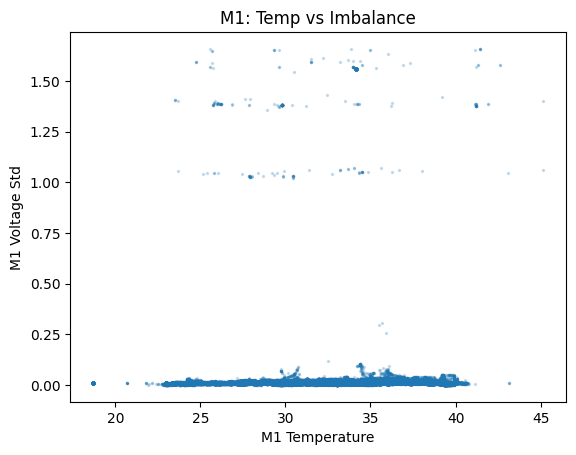

In [19]:
m1_v = silver_all[[c for c in voltage_cols if c.startswith("M1_")]]
m1_t = silver_all[[c for c in temp_cols if c.startswith("M1_")]]

m1_std = m1_v.std(axis=1)
m1_temp = m1_t.mean(axis=1)

import matplotlib.pyplot as plt
sample = pd.DataFrame({"temp": m1_temp, "std": m1_std}).sample(100000)

plt.scatter(sample["temp"], sample["std"], s=2, alpha=0.2)
plt.xlabel("M1 Temperature")
plt.ylabel("M1 Voltage Std")
plt.title("M1: Temp vs Imbalance")
plt.show()